# Streamflow Forecasting: Model Performance Report

**Transfer Learning with NeuralHydrology — CudaLSTM**

This notebook documents the current state of the streamflow forecasting models for two National Park watersheds:

- **Lamar River** (Yellowstone NP) — snowmelt-dominated, lag-1 autocorrelation = 0.986
- **Hoh River** (Olympic NP) — rain-dominated, lag-1 autocorrelation = 0.746

**Approach:** A CudaLSTM model pre-trained on 531 CAMELS US basins (Kratzert et al. 2021) is fine-tuned on each individual watershed using local GridMET climate data.

**Test period:** October 2020 – December 2024

> **Note on units:** The model internally predicts streamflow in mm/day (runoff depth normalized by basin area), which is standard in the NeuralHydrology / CAMELS framework. All values in this report have been converted to **cubic feet per second (CFS)** for practical interpretation. Dimensionless metrics (NSE, KGE, Pearson r) are unaffected by this conversion.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Basin areas (km²) from GAGES-II, used for mm/day → CFS conversion
BASIN_AREAS = {'lamar_lumped': 1730.1, 'hoh_lumped': 655.3}

def mm_per_day_to_cfs(values, area_km2):
    """Convert mm/day over a basin to cubic feet per second."""
    # mm/day → m³/s → cfs
    return values * area_km2 * 1000.0 / 86400.0 * 35.3147

# Load results and convert to CFS
def load_results(run_dir, basin, epoch=30):
    path = f"runs/{run_dir}/test/model_epoch{epoch:03d}/test_results.p"
    with open(path, 'rb') as f:
        results = pickle.load(f)
    data = results[basin]['1D']
    ds = data['xr']
    obs = ds['QObs_mm_d_obs'].values.squeeze()
    sim = ds['QObs_mm_d_sim'].values.squeeze()
    dates = pd.DatetimeIndex(ds.date.values)
    
    # Convert to CFS
    area = BASIN_AREAS[basin]
    obs_cfs = mm_per_day_to_cfs(obs, area)
    sim_cfs = mm_per_day_to_cfs(sim, area)
    
    metrics = {k: data[k] for k in ['NSE', 'KGE', 'RMSE', 'Pearson-r']}
    # Convert RMSE to CFS (same linear transform)
    metrics['RMSE'] = mm_per_day_to_cfs(metrics['RMSE'], area)
    
    return dates, obs_cfs, sim_cfs, metrics

# Lamar fine-tuned (best run)
lamar_ft_dates, lamar_ft_obs, lamar_ft_sim, lamar_ft_metrics = load_results(
    'lamar_finetune_3var_1103_115202', 'lamar_lumped')

# Hoh fine-tuned (best run)
hoh_ft_dates, hoh_ft_obs, hoh_ft_sim, hoh_ft_metrics = load_results(
    'hoh_finetune_3var_1103_115420', 'hoh_lumped')

# Scratch baselines (both from the same multi-basin run)
lamar_sc_dates, lamar_sc_obs, lamar_sc_sim, lamar_sc_metrics = load_results(
    'lamar_scratch_3var_0801_131332', 'lamar_lumped')
hoh_sc_dates, hoh_sc_obs, hoh_sc_sim, hoh_sc_metrics = load_results(
    'lamar_scratch_3var_0801_131332', 'hoh_lumped')

print("Data loaded successfully (all flows in CFS).")

Data loaded successfully (all flows in CFS).


## 1. Data Pipeline

Raw data sources are processed through a 4-step pipeline in `transfer_learning/src/`:

| Step | Script | Description |
|------|--------|-------------|
| 1 | `01_prep_climate_lumped.py` | Lump GridMET elevation-band climate to basin-mean |
| 2 | `02_convert_streamflow.py` | Convert USGS streamflow from CFS to mm/day |
| 3 | `03_merge_to_netcdf.py` | Merge climate + streamflow into NeuralHydrology NetCDF |
| 4 | `04_calculate_attributes.py` | Calculate 7 static basin attributes |

**Dynamic inputs (3):** `prcp_mm_day`, `tmax_C`, `tmin_C` (daily GridMET)

**Static attributes (7):** `elev_mean`, `slope_mean`, `area_gages2`, `frac_forest`, `soil_depth_pelletier`, `sand_frac`, `clay_frac`

**Date splits:**
- Train: Oct 1991 – Sep 2015 (24 years)
- Validation: Oct 2015 – Sep 2020 (5 years)
- Test: Oct 2020 – Dec 2024 (4.25 years)

## 2. Model Architecture & Training

### Pre-training
A CudaLSTM (hidden_size=256, dropout=0.4) was pre-trained on **531 CAMELS US basins** using Daymet forcing and NSE loss. The pre-trained checkpoint is stored in `base_model_modified/`.

### Fine-tuning
The pre-trained model is fine-tuned on each target watershed individually:

| Parameter | Value |
|-----------|-------|
| Model | CudaLSTM |
| Hidden size | 256 |
| Output dropout | 0.4 |
| Output activation | linear |
| Sequence length | 365 days |
| Loss | MSE |
| Optimizer | Adam |
| Learning rate | 1e-4 |
| Epochs | 30 |
| Fine-tuned modules | LSTM + head |

MSE is used instead of NSE for fine-tuning because it provides smoother gradients for single-basin optimization.

### From-scratch baseline
Following Kratzert et al. (2021) single-basin recommendations: hidden_size=32, NSE loss, lr=1e-3, 100 epochs. This represents the best practice for training without transfer learning — the smaller model avoids overfitting on limited single-basin data.

## 3. Test Period Results

In [2]:
# Summary metrics table
summary = pd.DataFrame([
    {'Watershed': 'Lamar River', 'Model': 'Transfer learning', 'NSE': lamar_ft_metrics['NSE'],
     'KGE': lamar_ft_metrics['KGE'], 'RMSE (CFS)': lamar_ft_metrics['RMSE'], 'Pearson r': lamar_ft_metrics['Pearson-r']},
    {'Watershed': 'Lamar River', 'Model': 'From-scratch baseline', 'NSE': lamar_sc_metrics['NSE'],
     'KGE': lamar_sc_metrics['KGE'], 'RMSE (CFS)': lamar_sc_metrics['RMSE'], 'Pearson r': lamar_sc_metrics['Pearson-r']},
    {'Watershed': 'Hoh River', 'Model': 'Transfer learning', 'NSE': hoh_ft_metrics['NSE'],
     'KGE': hoh_ft_metrics['KGE'], 'RMSE (CFS)': hoh_ft_metrics['RMSE'], 'Pearson r': hoh_ft_metrics['Pearson-r']},
    {'Watershed': 'Hoh River', 'Model': 'From-scratch baseline', 'NSE': hoh_sc_metrics['NSE'],
     'KGE': hoh_sc_metrics['KGE'], 'RMSE (CFS)': hoh_sc_metrics['RMSE'], 'Pearson r': hoh_sc_metrics['Pearson-r']},
])
summary = summary.set_index(['Watershed', 'Model'])
summary.style.format('{:.4f}').set_caption('Test Period Metrics (Oct 2020 – Dec 2024)')

### 3.1 Lamar River — Observed vs Predicted

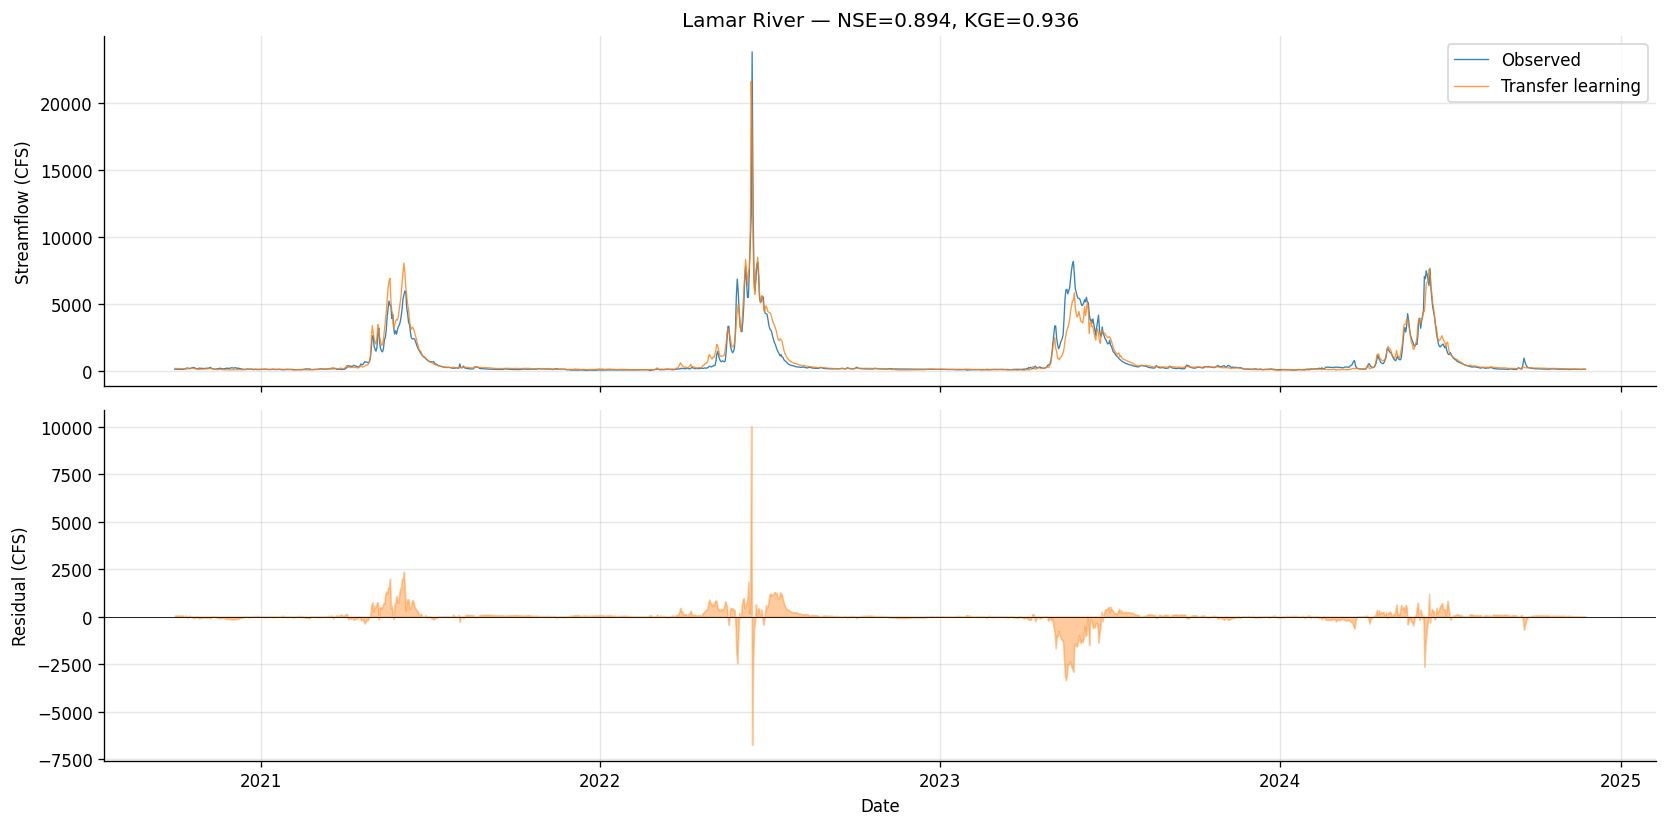

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Hydrograph
ax = axes[0]
ax.plot(lamar_ft_dates, lamar_ft_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(lamar_ft_dates, lamar_ft_sim, color='#ff7f0e', linewidth=0.8, label='Transfer learning', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Lamar River — NSE={lamar_ft_metrics["NSE"]:.3f}, KGE={lamar_ft_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Residuals
ax = axes[1]
residuals = lamar_ft_sim - lamar_ft_obs
ax.fill_between(lamar_ft_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 3.2 Hoh River — Observed vs Predicted

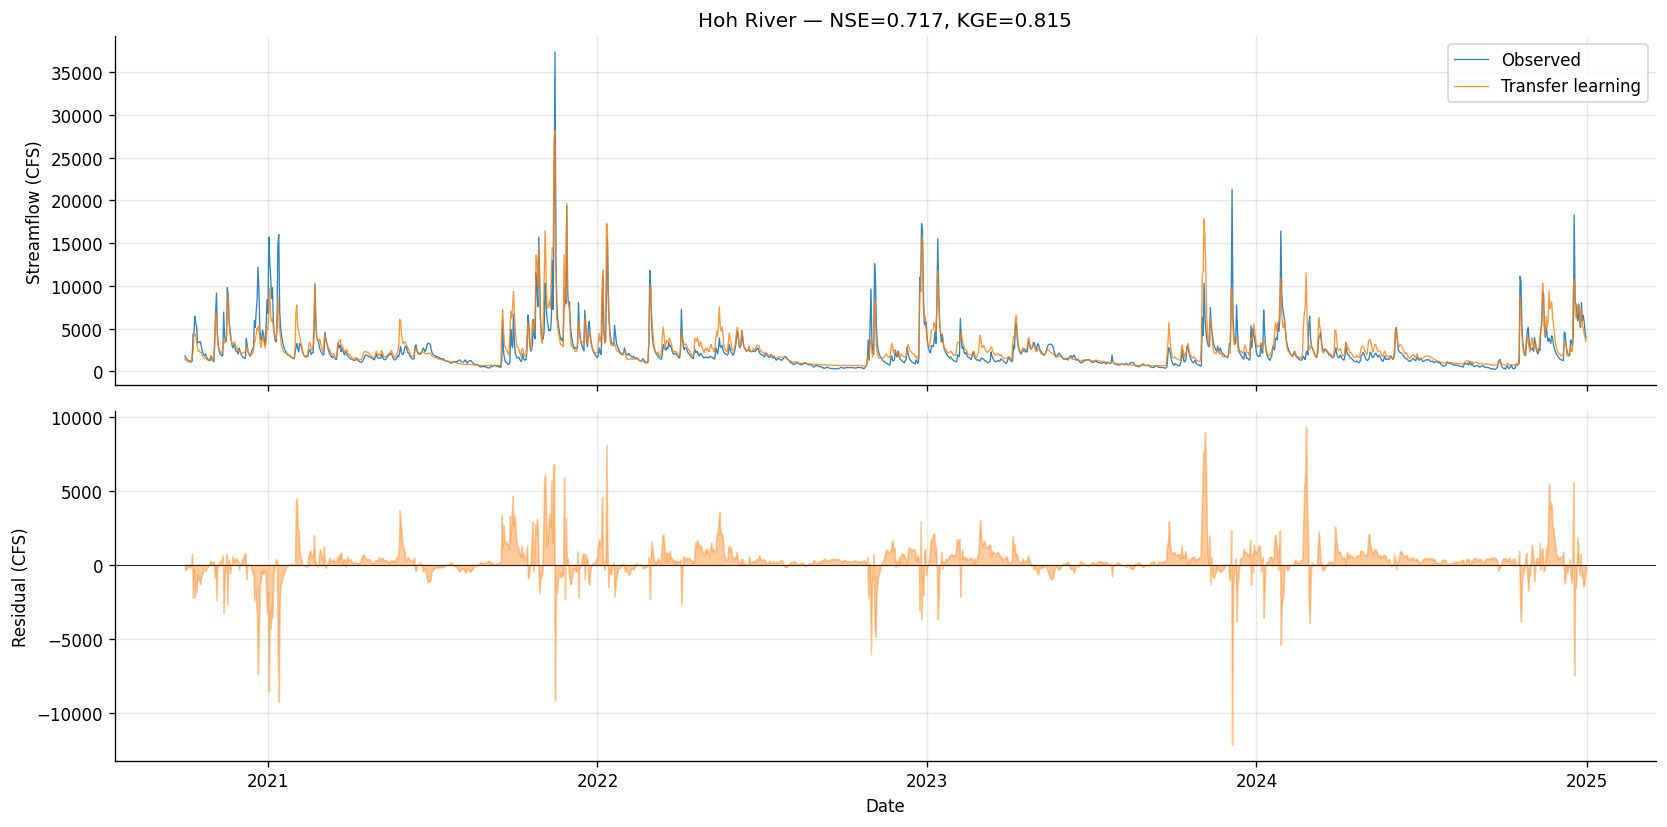

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Hydrograph
ax = axes[0]
ax.plot(hoh_ft_dates, hoh_ft_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(hoh_ft_dates, hoh_ft_sim, color='#ff7f0e', linewidth=0.8, label='Transfer learning', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Hoh River — NSE={hoh_ft_metrics["NSE"]:.3f}, KGE={hoh_ft_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Residuals
ax = axes[1]
residuals = hoh_ft_sim - hoh_ft_obs
ax.fill_between(hoh_ft_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 3.3 Scatter Plots — Observed vs Simulated

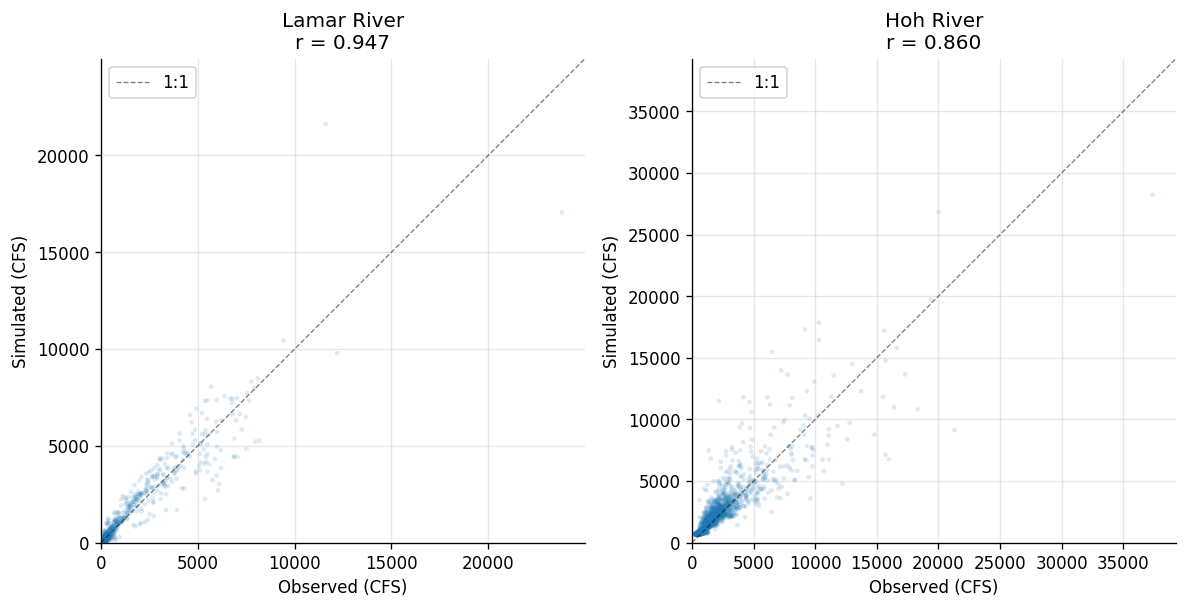

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, name, obs, sim, metrics in [
    (axes[0], 'Lamar River', lamar_ft_obs, lamar_ft_sim, lamar_ft_metrics),
    (axes[1], 'Hoh River', hoh_ft_obs, hoh_ft_sim, hoh_ft_metrics),
]:
    # Filter NaN
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    
    ax.scatter(o, s, alpha=0.15, s=8, color='#1f77b4', edgecolors='none')
    
    # 1:1 line
    lims = [0, max(o.max(), s.max()) * 1.05]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel('Observed (CFS)')
    ax.set_ylabel('Simulated (CFS)')
    ax.set_title(f'{name}\nr = {metrics["Pearson-r"]:.3f}')
    ax.set_aspect('equal')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Monthly Performance Breakdown

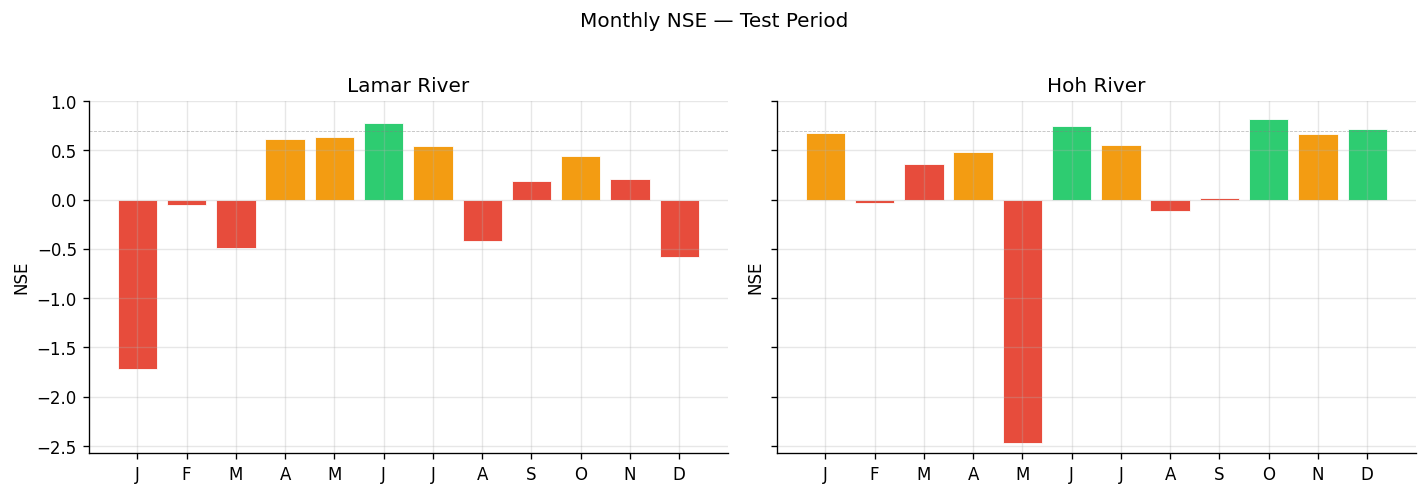

In [6]:
def monthly_nse(dates, obs, sim):
    """Compute NSE by calendar month."""
    df = pd.DataFrame({'obs': obs, 'sim': sim}, index=dates)
    df = df.dropna()
    results = {}
    for month in range(1, 13):
        m = df.index.month == month
        o, s = df.loc[m, 'obs'].values, df.loc[m, 'sim'].values
        ss_res = np.sum((o - s) ** 2)
        ss_tot = np.sum((o - np.mean(o)) ** 2)
        results[month] = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return results

lamar_monthly = monthly_nse(lamar_ft_dates, lamar_ft_obs, lamar_ft_sim)
hoh_monthly = monthly_nse(hoh_ft_dates, hoh_ft_obs, hoh_ft_sim)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for ax, name, monthly in [(axes[0], 'Lamar River', lamar_monthly), (axes[1], 'Hoh River', hoh_monthly)]:
    months = list(monthly.keys())
    values = list(monthly.values())
    colors = ['#2ecc71' if v >= 0.7 else '#f39c12' if v >= 0.4 else '#e74c3c' for v in values]
    ax.bar(months, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(months)
    ax.set_xticklabels(month_names)
    ax.set_ylabel('NSE')
    ax.set_title(name)
    ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_ylim(min(0, min(values) - 0.1), 1.0)

plt.suptitle('Monthly NSE — Test Period', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Flow Duration Curves

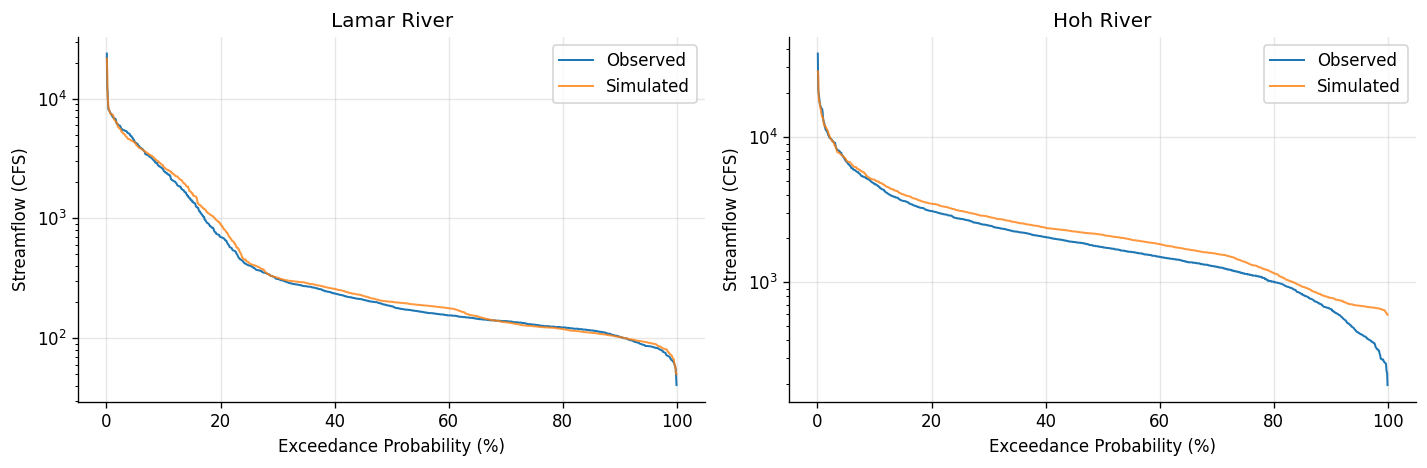

In [7]:
def flow_duration_curve(values):
    """Return exceedance probabilities and sorted flows."""
    sorted_vals = np.sort(values[~np.isnan(values)])[::-1]
    ranks = np.arange(1, len(sorted_vals) + 1)
    exceedance = ranks / (len(sorted_vals) + 1) * 100
    return exceedance, sorted_vals

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, obs, sim in [
    (axes[0], 'Lamar River', lamar_ft_obs, lamar_ft_sim),
    (axes[1], 'Hoh River', hoh_ft_obs, hoh_ft_sim),
]:
    exc_obs, fdc_obs = flow_duration_curve(obs)
    exc_sim, fdc_sim = flow_duration_curve(sim)
    
    ax.semilogy(exc_obs, fdc_obs, color='#1f77b4', linewidth=1.2, label='Observed')
    ax.semilogy(exc_sim, fdc_sim, color='#ff7f0e', linewidth=1.2, label='Simulated', alpha=0.8)
    ax.set_xlabel('Exceedance Probability (%)')
    ax.set_ylabel('Streamflow (CFS)')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

### 3.6 Transfer Learning vs From-Scratch Comparison

The from-scratch baselines use the Kratzert et al. (2021) recommended single-basin architecture (hidden_size=32, NSE loss, lr=1e-3, 100 epochs). This is a best-practice comparison: "what would you build without access to a pre-trained regional model?"

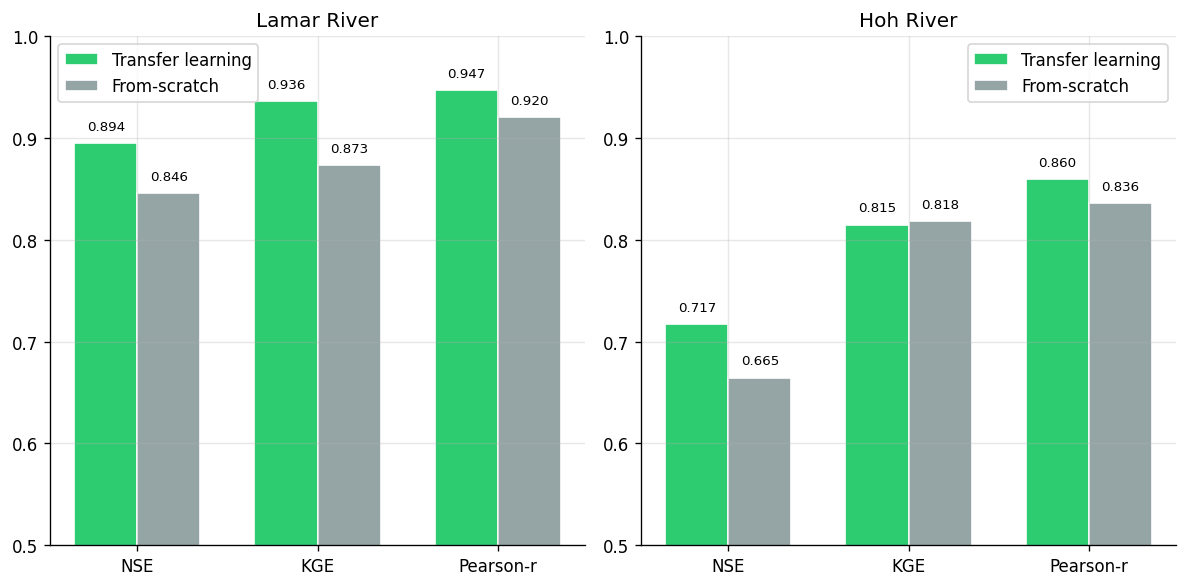

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, name, ft_m, sc_m in [
    (axes[0], 'Lamar River', lamar_ft_metrics, lamar_sc_metrics),
    (axes[1], 'Hoh River', hoh_ft_metrics, hoh_sc_metrics),
]:
    metrics_list = ['NSE', 'KGE', 'Pearson-r']
    ft_vals = [ft_m[m] for m in metrics_list]
    sc_vals = [sc_m[m] for m in metrics_list]
    
    x = np.arange(len(metrics_list))
    w = 0.35
    ax.bar(x - w/2, ft_vals, w, label='Transfer learning', color='#2ecc71', edgecolor='white')
    ax.bar(x + w/2, sc_vals, w, label='From-scratch', color='#95a5a6', edgecolor='white')
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_list)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(name)
    ax.legend()

    # Add value labels
    for i, (fv, sv) in enumerate(zip(ft_vals, sc_vals)):
        ax.text(i - w/2, fv + 0.01, f'{fv:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + w/2, sv + 0.01, f'{sv:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 3.7 From-Scratch Baseline — Time Series

Hydrographs for the from-scratch models (hidden_size=32, NSE loss, 100 epochs) on the test period. Compare with sections 3.1–3.2 to see the transfer learning advantage visually.

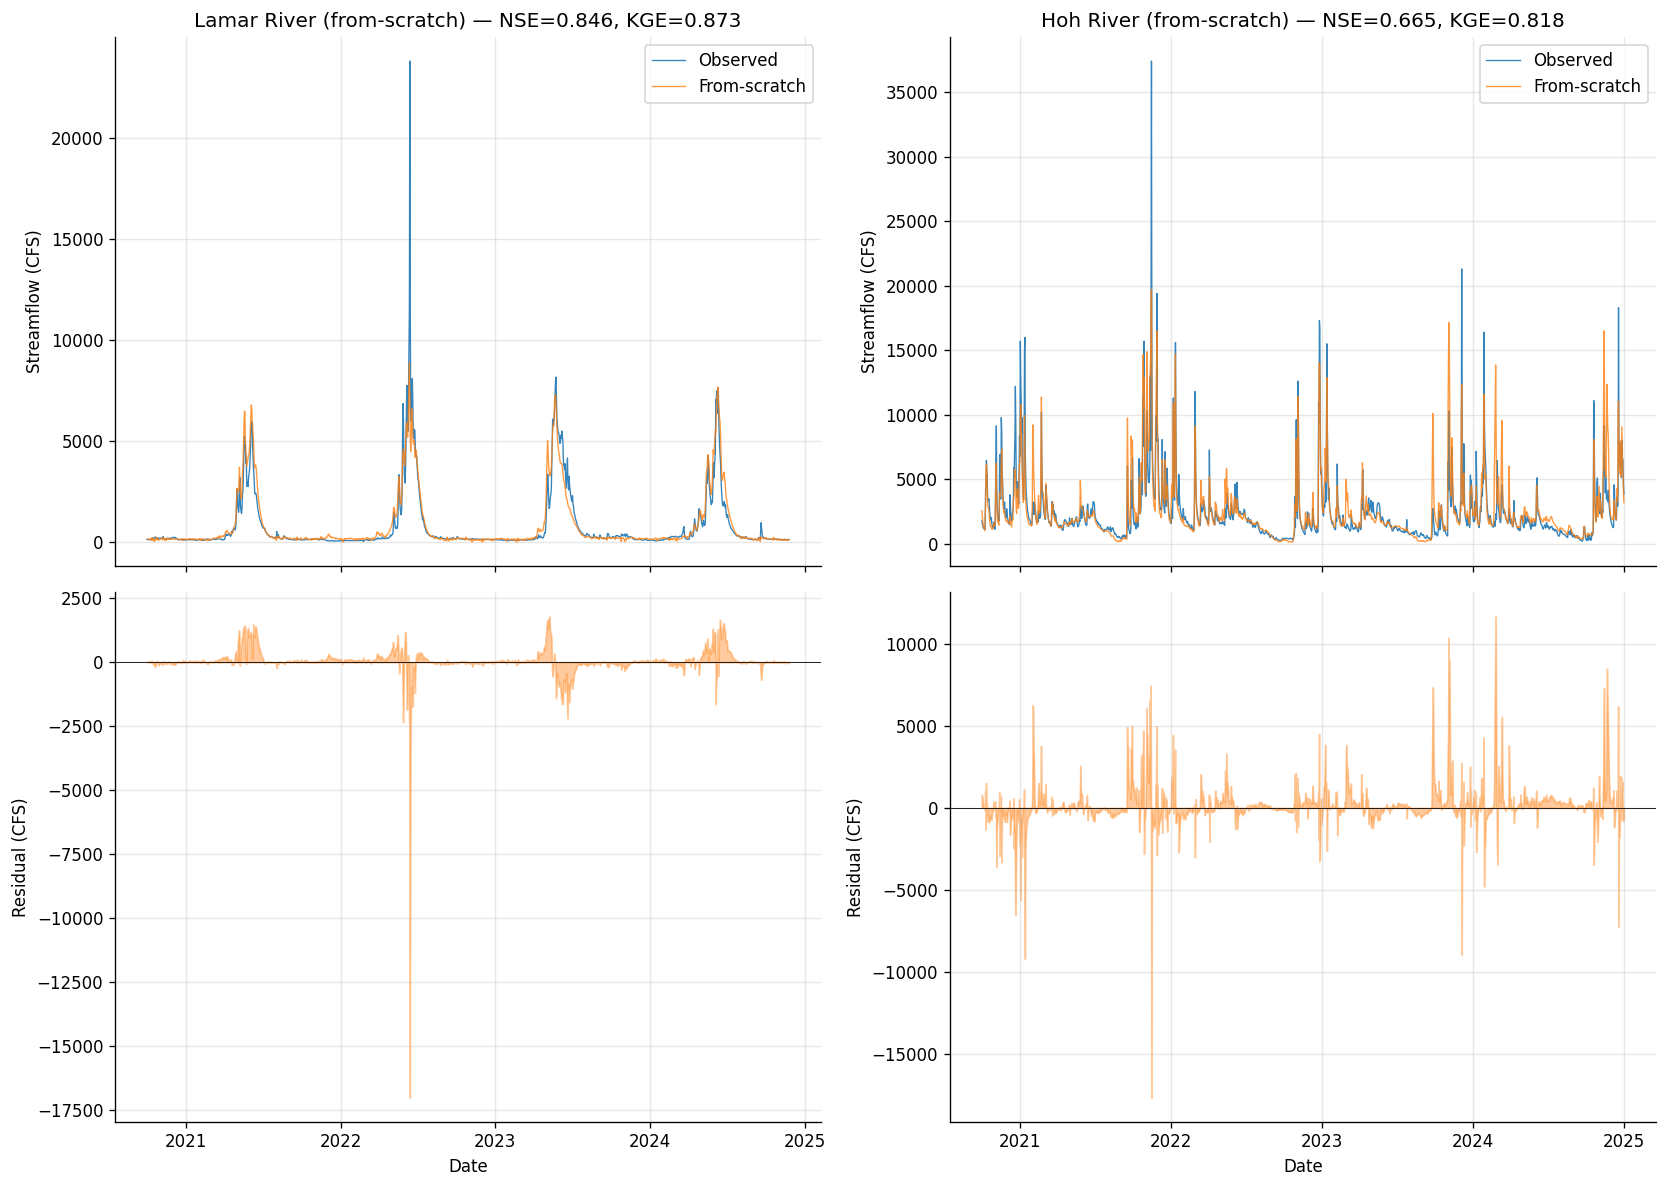

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex='col')

# Lamar scratch — hydrograph
ax = axes[0, 0]
ax.plot(lamar_sc_dates, lamar_sc_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(lamar_sc_dates, lamar_sc_sim, color='#ff7f0e', linewidth=0.8, label='From-scratch', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Lamar River (from-scratch) — NSE={lamar_sc_metrics["NSE"]:.3f}, KGE={lamar_sc_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Lamar scratch — residuals
ax = axes[1, 0]
residuals = lamar_sc_sim - lamar_sc_obs
ax.fill_between(lamar_sc_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Hoh scratch — hydrograph
ax = axes[0, 1]
ax.plot(hoh_sc_dates, hoh_sc_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(hoh_sc_dates, hoh_sc_sim, color='#ff7f0e', linewidth=0.8, label='From-scratch', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Hoh River (from-scratch) — NSE={hoh_sc_metrics["NSE"]:.3f}, KGE={hoh_sc_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Hoh scratch — residuals
ax = axes[1, 1]
residuals = hoh_sc_sim - hoh_sc_obs
ax.fill_between(hoh_sc_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 3.8 Peak Flow Analysis

Transfer learning's primary advantage is better peak flow capture. The from-scratch model fits baseflow well but underestimates peaks — this section quantifies and visualizes that difference.

#### High-flow metrics
NSE and KGE computed only on days where observed flow exceeds the 90th percentile. This isolates model performance on the flows that matter most for flood forecasting and ecological assessment.

In [10]:
def high_flow_metrics(obs, sim, threshold_pct=90):
    """Compute NSE, KGE, and peak ratio on days above an observed flow percentile."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    threshold = np.percentile(o, threshold_pct)
    high = o >= threshold
    o_h, s_h = o[high], s[high]
    
    # NSE
    ss_res = np.sum((o_h - s_h) ** 2)
    ss_tot = np.sum((o_h - np.mean(o_h)) ** 2)
    nse = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    
    # KGE
    r = np.corrcoef(o_h, s_h)[0, 1]
    alpha = np.std(s_h) / np.std(o_h)
    beta = np.mean(s_h) / np.mean(o_h)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    
    # Mean peak ratio
    peak_ratio = np.mean(s_h) / np.mean(o_h)
    
    return {'NSE (high)': nse, 'KGE (high)': kge, 'Mean peak ratio': peak_ratio,
            'N days': int(high.sum()), 'Threshold (CFS)': threshold}

rows = []
for name, ft_obs, ft_sim, sc_obs, sc_sim in [
    ('Lamar River', lamar_ft_obs, lamar_ft_sim, lamar_sc_obs, lamar_sc_sim),
    ('Hoh River', hoh_ft_obs, hoh_ft_sim, hoh_sc_obs, hoh_sc_sim),
]:
    ft_hf = high_flow_metrics(ft_obs, ft_sim)
    sc_hf = high_flow_metrics(sc_obs, sc_sim)
    rows.append({'Watershed': name, 'Model': 'Transfer learning', **ft_hf})
    rows.append({'Watershed': name, 'Model': 'From-scratch', **sc_hf})

hf_df = pd.DataFrame(rows).set_index(['Watershed', 'Model'])
hf_df.style.format({
    'NSE (high)': '{:.3f}', 'KGE (high)': '{:.3f}', 'Mean peak ratio': '{:.3f}',
    'N days': '{:d}', 'Threshold (CFS)': '{:.1f}'
}).set_caption('Metrics on top 10% flow days (≥ 90th percentile)')

#### Annual peak magnitude

Observed vs simulated water-year maxima. Points below the 1:1 line indicate peak underestimation.

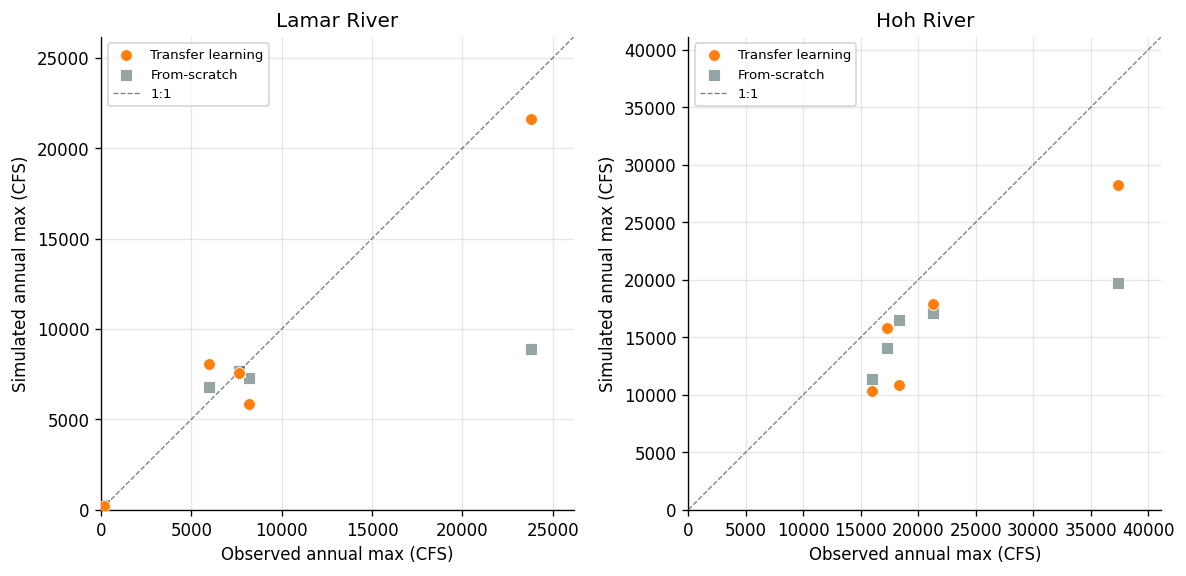

In [11]:
def annual_peaks(dates, obs, sim):
    """Return water-year annual maxima for obs and sim."""
    df = pd.DataFrame({'obs': obs, 'sim': sim}, index=dates).dropna()
    # Water year: Oct start, label by the year containing Jan
    df['wy'] = df.index.year + (df.index.month >= 10).astype(int)
    peaks = df.groupby('wy').max()
    return peaks['obs'].values, peaks['sim'].values, peaks.index.values

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, name, ft_dates, ft_obs, ft_sim, sc_dates, sc_obs, sc_sim in [
    (axes[0], 'Lamar River', lamar_ft_dates, lamar_ft_obs, lamar_ft_sim,
     lamar_sc_dates, lamar_sc_obs, lamar_sc_sim),
    (axes[1], 'Hoh River', hoh_ft_dates, hoh_ft_obs, hoh_ft_sim,
     hoh_sc_dates, hoh_sc_obs, hoh_sc_sim),
]:
    ft_peak_obs, ft_peak_sim, ft_wys = annual_peaks(ft_dates, ft_obs, ft_sim)
    sc_peak_obs, sc_peak_sim, sc_wys = annual_peaks(sc_dates, sc_obs, sc_sim)
    
    ax.scatter(ft_peak_obs, ft_peak_sim, s=50, color='#ff7f0e', zorder=3,
               label='Transfer learning', edgecolors='white', linewidth=0.5)
    ax.scatter(sc_peak_obs, sc_peak_sim, s=50, color='#95a5a6', zorder=2,
               marker='s', label='From-scratch', edgecolors='white', linewidth=0.5)
    
    # 1:1 line
    all_vals = np.concatenate([ft_peak_obs, ft_peak_sim, sc_peak_obs, sc_peak_sim])
    lims = [0, np.max(all_vals) * 1.1]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel('Observed annual max (CFS)')
    ax.set_ylabel('Simulated annual max (CFS)')
    ax.set_title(name)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Peak event overlays

Zoomed views of the top 4 peak events per watershed, showing both models on the same axes. A ±30 day window around each observed annual maximum highlights how each model handles the peak hydrograph shape.

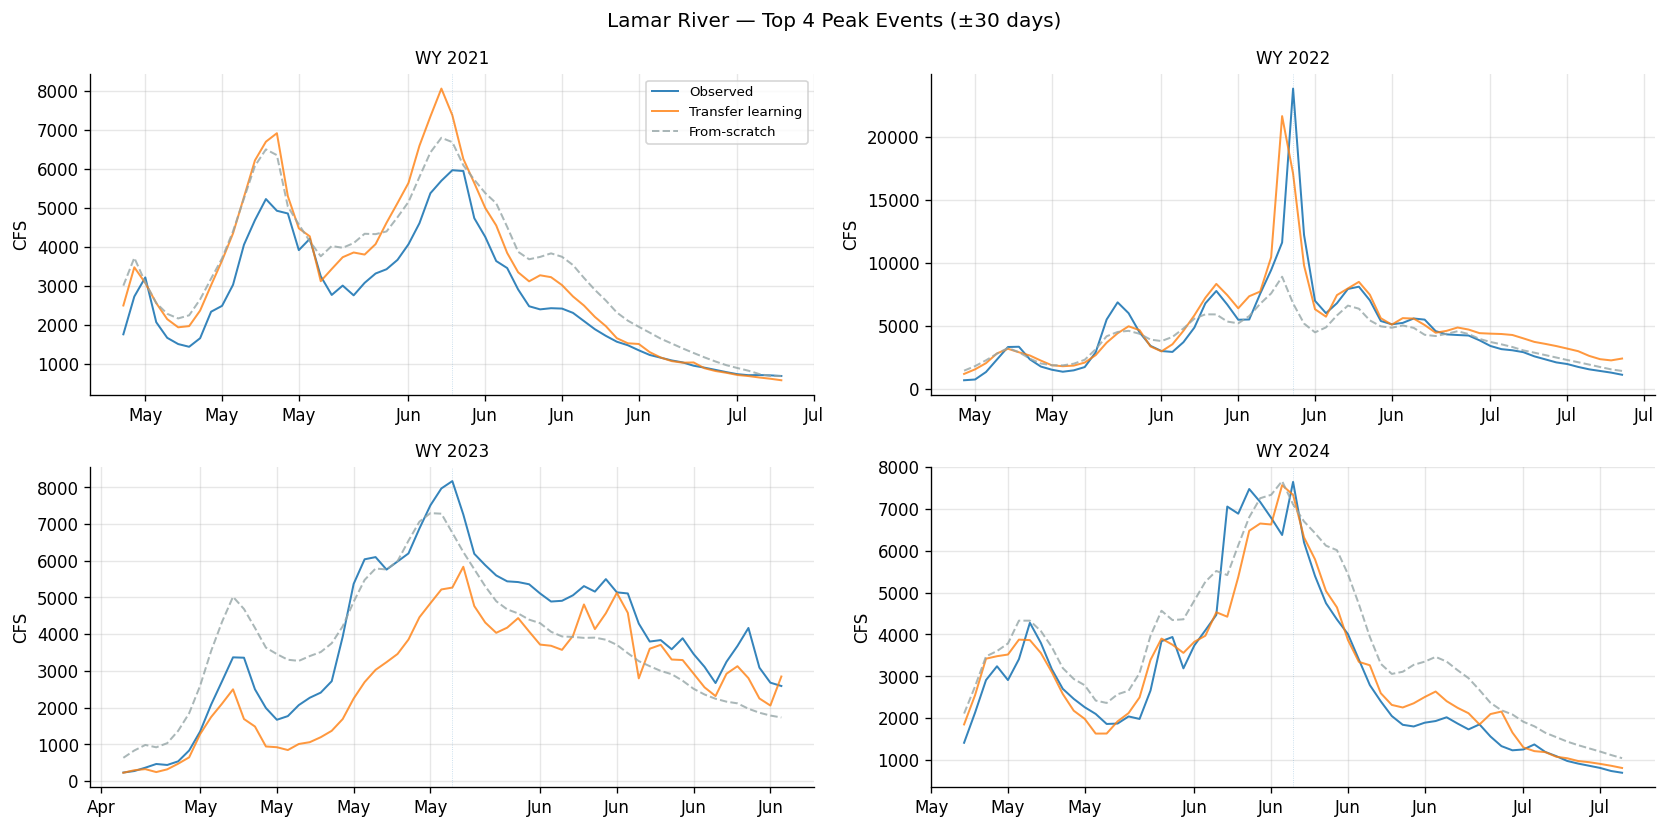

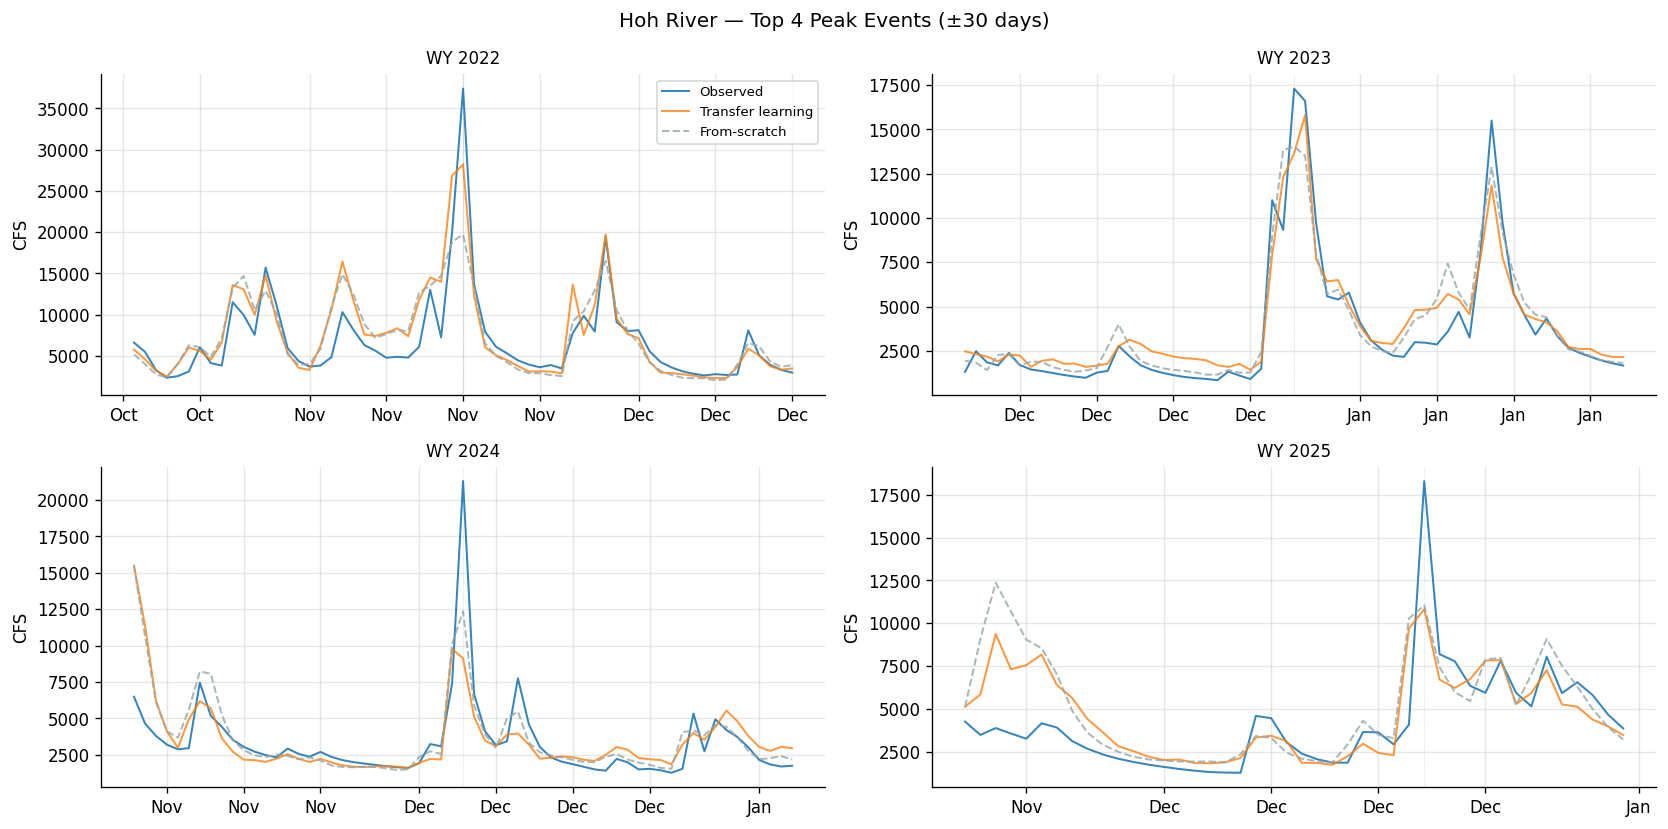

In [12]:
def find_peak_windows(dates, obs, n_peaks=4, window_days=30):
    """Find dates of top n annual peaks and return ±window slices."""
    df = pd.DataFrame({'obs': obs}, index=dates).dropna()
    df['wy'] = df.index.year + (df.index.month >= 10).astype(int)
    # Get date of max flow in each water year
    peak_dates = df.groupby('wy')['obs'].idxmax()
    # Get peak magnitudes, sort descending, take top n
    peak_vals = df.loc[peak_dates.values, 'obs']
    top_idx = peak_vals.sort_values(ascending=False).index[:n_peaks]
    top_dates = sorted(top_idx)
    
    windows = []
    for pd_date in top_dates:
        start = pd_date - pd.Timedelta(days=window_days)
        end = pd_date + pd.Timedelta(days=window_days)
        windows.append((start, end, pd_date))
    return windows

for basin_name, ft_dates, ft_obs, ft_sim, sc_dates, sc_obs, sc_sim in [
    ('Lamar River', lamar_ft_dates, lamar_ft_obs, lamar_ft_sim,
     lamar_sc_dates, lamar_sc_obs, lamar_sc_sim),
    ('Hoh River', hoh_ft_dates, hoh_ft_obs, hoh_ft_sim,
     hoh_sc_dates, hoh_sc_obs, hoh_sc_sim),
]:
    windows = find_peak_windows(ft_dates, ft_obs, n_peaks=4, window_days=30)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    axes = axes.flatten()
    
    ft_df = pd.DataFrame({'obs': ft_obs, 'ft_sim': ft_sim}, index=ft_dates)
    sc_df = pd.DataFrame({'sc_sim': sc_sim}, index=sc_dates)
    
    for i, (start, end, peak_date) in enumerate(windows):
        ax = axes[i]
        ft_win = ft_df.loc[start:end]
        sc_win = sc_df.loc[start:end]
        
        ax.plot(ft_win.index, ft_win['obs'], color='#1f77b4', linewidth=1.2,
                label='Observed', alpha=0.9)
        ax.plot(ft_win.index, ft_win['ft_sim'], color='#ff7f0e', linewidth=1.2,
                label='Transfer learning', alpha=0.8)
        ax.plot(sc_win.index, sc_win['sc_sim'], color='#95a5a6', linewidth=1.2,
                label='From-scratch', linestyle='--', alpha=0.8)
        
        ax.axvline(peak_date, color='#1f77b4', linewidth=0.5, alpha=0.3, linestyle=':')
        ax.set_title(f'WY {peak_date.year + (peak_date.month >= 10)}', fontsize=10)
        ax.set_ylabel('CFS')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        if i == 0:
            ax.legend(fontsize=8)
    
    plt.suptitle(f'{basin_name} — Top 4 Peak Events (±30 days)', fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. How to Reproduce

### Environment setup
```bash
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt  # torch, neuralhydrology, pandas, etc.
```

Requires NVIDIA GPU with CUDA (tested on GTX 1070).

### Data pipeline
```bash
# Download raw data
python src/download_lamar_river_data.py
python src/download_hoh_river_data.py
python src/download_gridmet_generalized.py
python src/download_snotel.py

# Process into NeuralHydrology format
cd transfer_learning
python src/01_prep_climate_lumped.py
python src/02_convert_streamflow.py
python src/03_merge_to_netcdf.py
python src/04_calculate_attributes.py
```

### Training
All `nh-run` commands must be run from the `transfer_learning/` directory (configs use relative paths).

```bash
cd transfer_learning

# Fine-tune Lamar
nh-run finetune --config-file config/lamar_finetune_3var.yml

# Fine-tune Hoh
nh-run finetune --config-file config/hoh_finetune_3var.yml

# Evaluate
nh-run evaluate --run-dir runs/<run_name> --epoch 30 --period test
```

### Key files
| File | Purpose |
|------|---------|
| `config/lamar_finetune_3var.yml` | Lamar fine-tuning config |
| `config/hoh_finetune_3var.yml` | Hoh fine-tuning config |
| `base_model_modified/` | Pre-trained CAMELS checkpoint (required for fine-tuning) |
| `dashboard.py` | Interactive Streamlit evaluation dashboard |
| `tests/` | Pipeline validation tests (`python -m pytest tests/ -v`) |

### Gotchas
1. **Configs must use relative paths** — always run `nh-run` from `transfer_learning/`
2. **`base_model_modified/` must exist** with the checkpoint and scaler files for fine-tuning to work
3. **Variable name mismatch:** CAMELS uses `prcp(mm/day)`, local NetCDF uses `prcp_mm_day` — the `scripts/create_modified_base_model.py` script handles this mapping
4. **Never shuffle temporal data** — date splits must be strictly chronological

## 5. Assessment & Next Steps

### Performance summary

The primary goal of these models is **peak flow prediction for flood warning**. Overall metrics are strong (Lamar NSE=0.89, Hoh NSE=0.72), but the high-flow metrics tell a more nuanced story:

| | Lamar (transfer) | Lamar (scratch) | Hoh (transfer) | Hoh (scratch) |
|---|---|---|---|---|
| **Overall NSE** | 0.895 | 0.846 | 0.717 | 0.665 |
| **High-flow NSE (≥P90)** | 0.575 | 0.396 | 0.417 | 0.412 |
| **High-flow KGE (≥P90)** | 0.791 | 0.467 | 0.705 | 0.638 |
| **Peak ratio** | 0.97 | 0.96 | 0.92 | 0.96 |
| **Volume bias** | +3.6% | +5.9% | +11.3% | +7.8% |

**Key findings:**
- **Transfer learning clearly helps Lamar peaks** — high-flow KGE jumps from 0.467 to 0.791, and the peak event overlays show the scratch model consistently clipping snowmelt peaks.
- **Hoh improvement is marginal** — high-flow NSE is essentially the same (0.417 vs 0.412). The CAMELS base model, trained mostly on continental/eastern US basins, may not transfer as well to Pacific maritime rain-dominated hydrology.
- **Both models underestimate peaks** — peak ratios below 1.0 for all models, with Hoh transfer learning showing the most underestimation (0.92).
- **Seasonal weaknesses exist but are not critical for flood warning** — poor winter NSE (Lamar Dec–Mar, negative) and Hoh May (NSE=-2.47) reflect low-flow periods or seasonal transitions that don't coincide with flood risk windows. Lamar flood risk is June snowmelt (NSE=0.77); Hoh flood risk is Nov–Jan storms (NSE=0.66–0.71).

### Next steps (prioritized for peak/flood prediction)

**1. High-flow weighted loss (fine-tuning only)**
Weight the MSE loss toward high-flow days during fine-tuning so the model prioritizes peak accuracy over baseflow fit. The current uniform MSE spends model capacity fitting low-flow winter months that are irrelevant for flood warning. NeuralHydrology supports custom loss functions. No base model changes required — config-level change.

**2. MC-Dropout prediction intervals (inference only)**
For operational flood warning, the key question is whether the *upper bound* of the prediction interval crosses a flood threshold — not whether the point prediction does. The model already has dropout=0.4; MC-Dropout runs inference N times with dropout enabled and derives prediction intervals from the spread. This is a few lines of evaluation code with no retraining needed.

**3. Fine-tuning hyperparameter search for Hoh (fine-tuning only)**
The thin transfer learning advantage on Hoh (NSE +0.05 over scratch) suggests the current fine-tuning setup isn't extracting much from the base model for this basin. Try: unfreezing more layers, warmup + cosine LR schedule, or longer training. All config-level changes.

**4. Hoh forcing bias investigation (diagnostic)**
The +11.3% wet volume bias on Hoh may originate in the GridMET forcing data — orographic effects are extreme on the Olympic Peninsula and GridMET is known to struggle there. Compare GridMET precipitation against PRISM or the Hoh rain gauge. If the bias is in the inputs, a simple correction could help without touching the model.

**5. SNOTEL SWE as 4th dynamic input (requires base model retrain)**
Adding SWE would likely improve Lamar's snowmelt timing, but this requires retraining the base model on all 531 CAMELS basins with a gridded SWE product (SNOTEL coverage is too sparse for CAMELS-wide use). This is a major pipeline effort — months of work — and the Lamar peak-season performance (June NSE=0.77, peak ratio=0.97) is already reasonable. **Defer unless the other improvements plateau.**

### Related resources
- `dashboard.py` — Interactive Streamlit app for exploring individual run results
- `archive/` — Historical notebooks from earlier modeling approaches (stages 1–6)